# 🛒 Superstore Sales — Exploratory Data Analysis

**Author:** Jasjot Singh  
**Dataset:** [Kaggle Superstore Sales Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  
**Goal:** Perform a full EDA to uncover patterns in sales, profit, discounts, and regional performance across a US retail superstore.

---


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


---
## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9,
                     'ytick.labelsize': 9})
ACCENT = '#2563EB'

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


---
## 2. Data Cleaning & Quality Check



In [3]:

print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Data Types ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Dupli

In [4]:

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=False)


df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Profit Margin'] = df['Profit'] / df['Sales']

print('Date range:', df['Order Date'].min().date(), '→', df['Order Date'].max().date())
print('Years covered:', sorted(df['Order Year'].unique()))

Date range: 2014-01-03 → 2017-12-30
Years covered: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]


In [5]:

print(df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().round(2))
print()
print(f"Negative profit rows : {(df['Profit'] < 0).sum()}")
print(f"Zero-sales rows      : {(df['Sales'] == 0).sum()}")
print(f"Discount range       : {df['Discount'].min()} – {df['Discount'].max()}")

          Sales   Profit  Discount  Quantity
count   9994.00  9994.00   9994.00   9994.00
mean     229.86    28.66      0.16      3.79
std      623.25   234.26      0.21      2.23
min        0.44 -6599.98      0.00      1.00
25%       17.28     1.73      0.00      2.00
50%       54.49     8.67      0.20      3.00
75%      209.94    29.36      0.20      5.00
max    22638.48  8399.98      0.80     14.00

Negative profit rows : 1871
Zero-sales rows      : 0
Discount range       : 0.0 – 0.8


**Cleaning notes:**
- No missing values — dataset is complete.
- Dates parsed successfully; dataset spans 2014–2017.
- There are rows with negative profit — these are real loss-making orders, not errors. We keep them as they are analytically important.
- Discounts go up to 80% — we'll investigate the impact of high discounts in the bivariate section.

---
## 3. Univariate Analysis



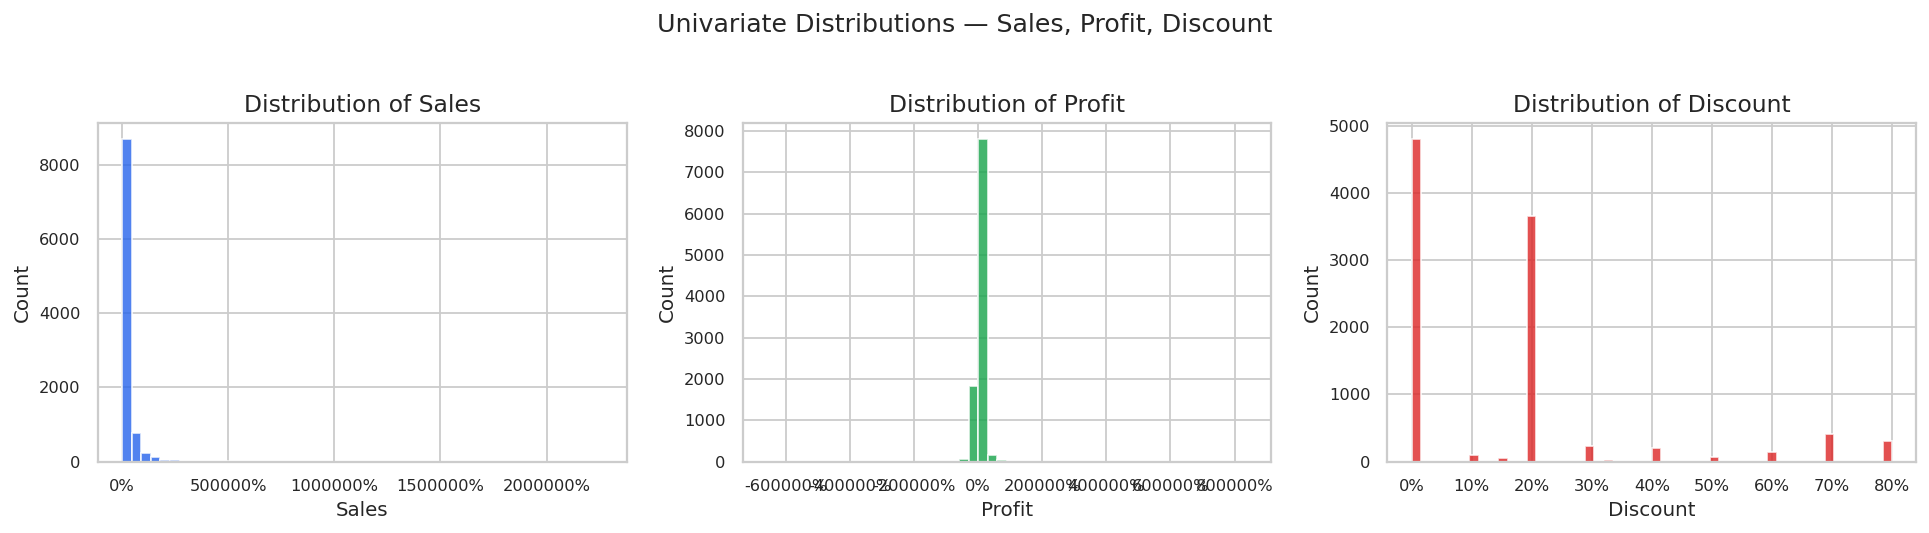

In [6]:
# ── Distributions of Sales, Profit, Discount ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                          ['Sales', 'Profit', 'Discount'],
                          ['#2563EB', '#16A34A', '#DC2626']):
    ax.hist(df[col], bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x:,.0f}' if col != 'Discount' else f'{x:.0%}'))

plt.suptitle('Univariate Distributions — Sales, Profit, Discount',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_distributions.png', bbox_inches='tight')
plt.show()

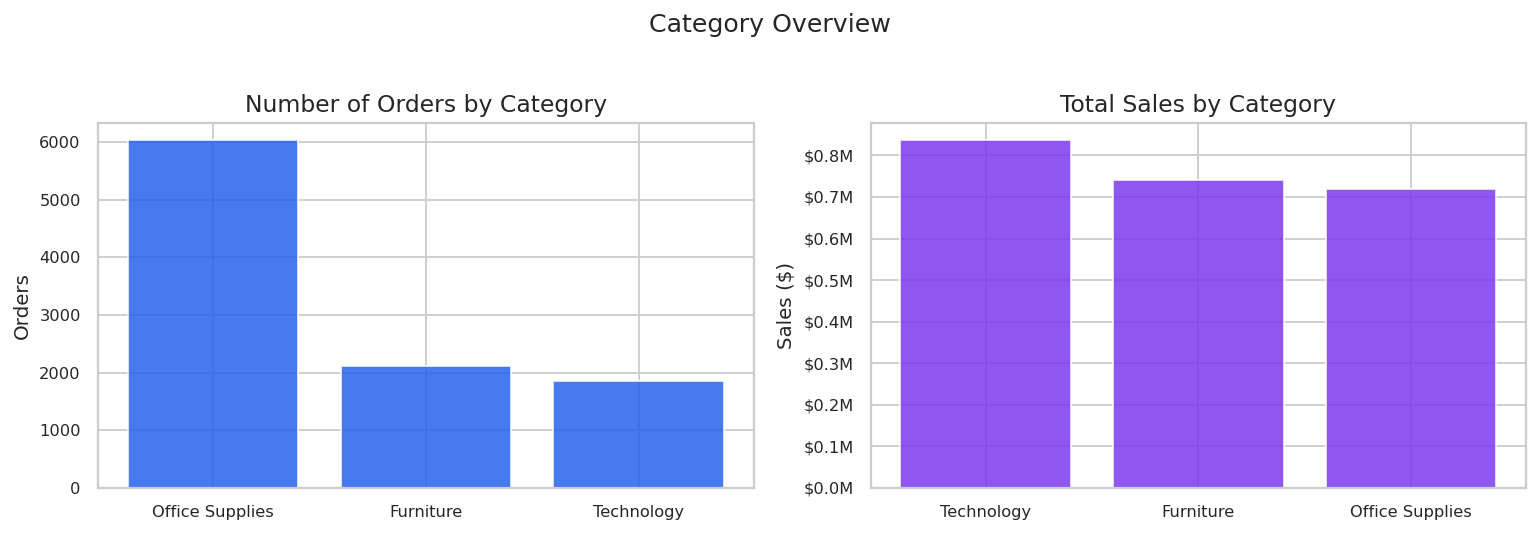


Category Sales Summary:
                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95


In [7]:
# ── Orders and Revenue by Category ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cat_orders = df['Category'].value_counts()
cat_sales  = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

axes[0].bar(cat_orders.index, cat_orders.values, color=ACCENT, alpha=0.85)
axes[0].set_title('Number of Orders by Category')
axes[0].set_ylabel('Orders')

axes[1].bar(cat_sales.index, cat_sales.values, color='#7C3AED', alpha=0.85)
axes[1].set_title('Total Sales by Category')
axes[1].set_ylabel('Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Category Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig2_category_overview.png', bbox_inches='tight')
plt.show()

print('\nCategory Sales Summary:')
print(df.groupby('Category')[['Sales','Profit']].sum().round(2))

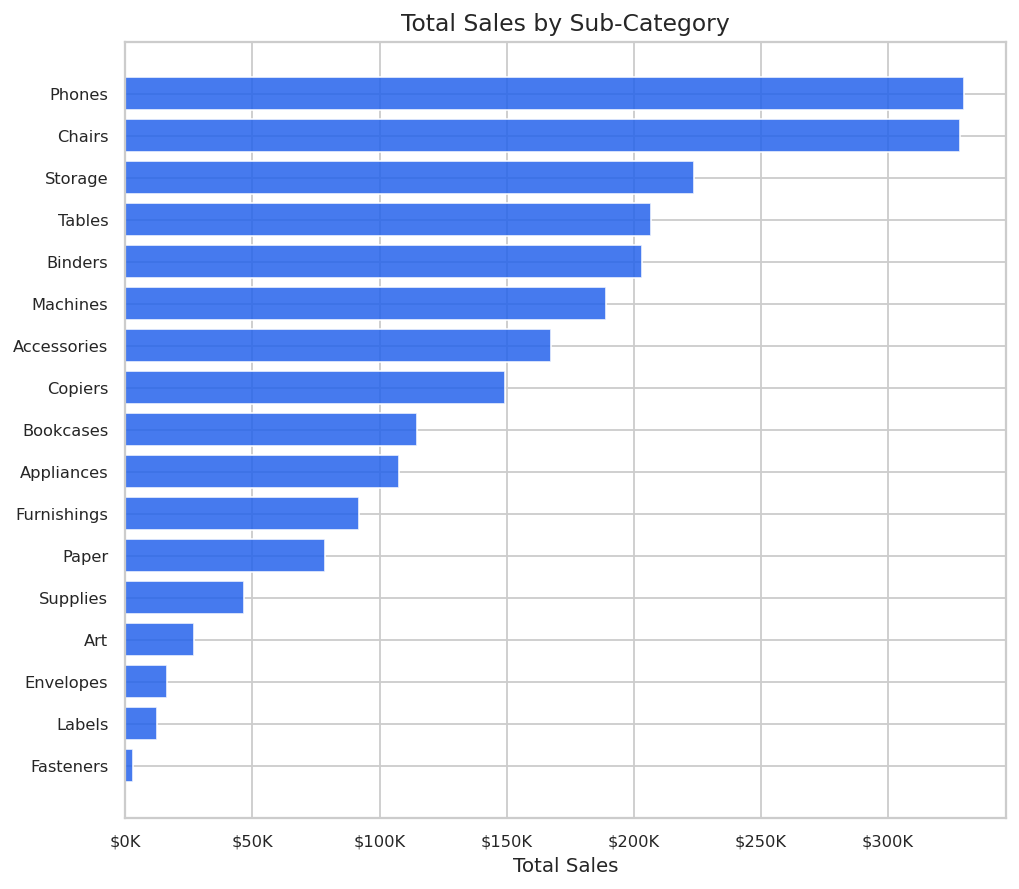

In [8]:
# ── Sub-Category Revenue Ranking ─────────────────────────────────────────
sub_sales = (df.groupby('Sub-Category')['Sales']
               .sum()
               .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(sub_sales.index, sub_sales.values, color=ACCENT, alpha=0.85)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Total Sales by Sub-Category', fontsize=13)
ax.set_xlabel('Total Sales')
plt.tight_layout()
plt.savefig('fig3_subcategory_sales.png', bbox_inches='tight')
plt.show()

**Univariate Observations:**
- **Sales** is heavily right-skewed — most orders are small, with a long tail of high-value orders.
- **Profit** is centred near zero with a notable left tail — many loss-making orders exist.
- **Discount** spikes at round numbers (0%, 20%, 30%, 50%) suggesting manual discounting policies.
- Technology leads in total revenue despite having fewer orders than Office Supplies — higher average order value.
- Phones and Chairs are the top sub-categories by revenue.

---
## 4. Bivariate Analysis



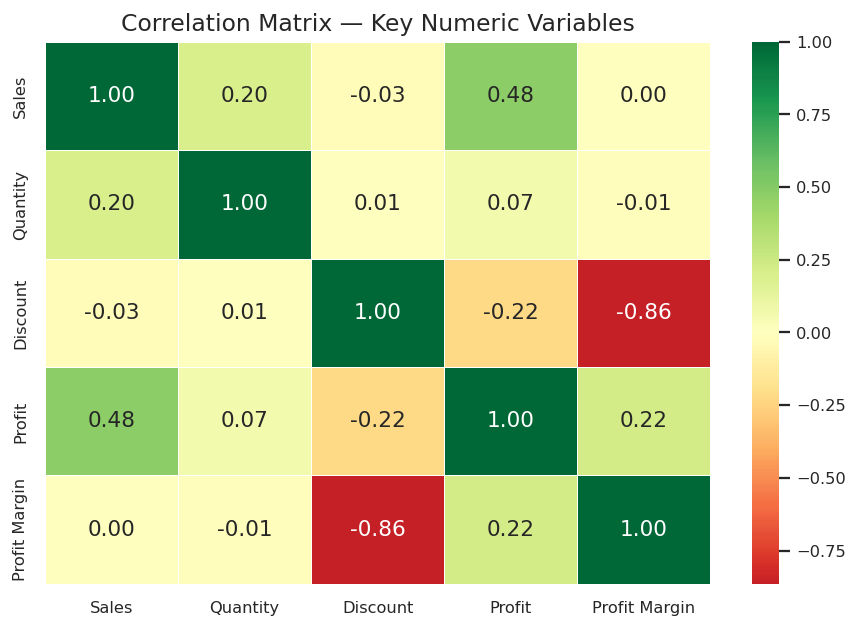

In [9]:
# ── Correlation Heatmap ──────────────────────────────────────────────────
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Key Numeric Variables', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

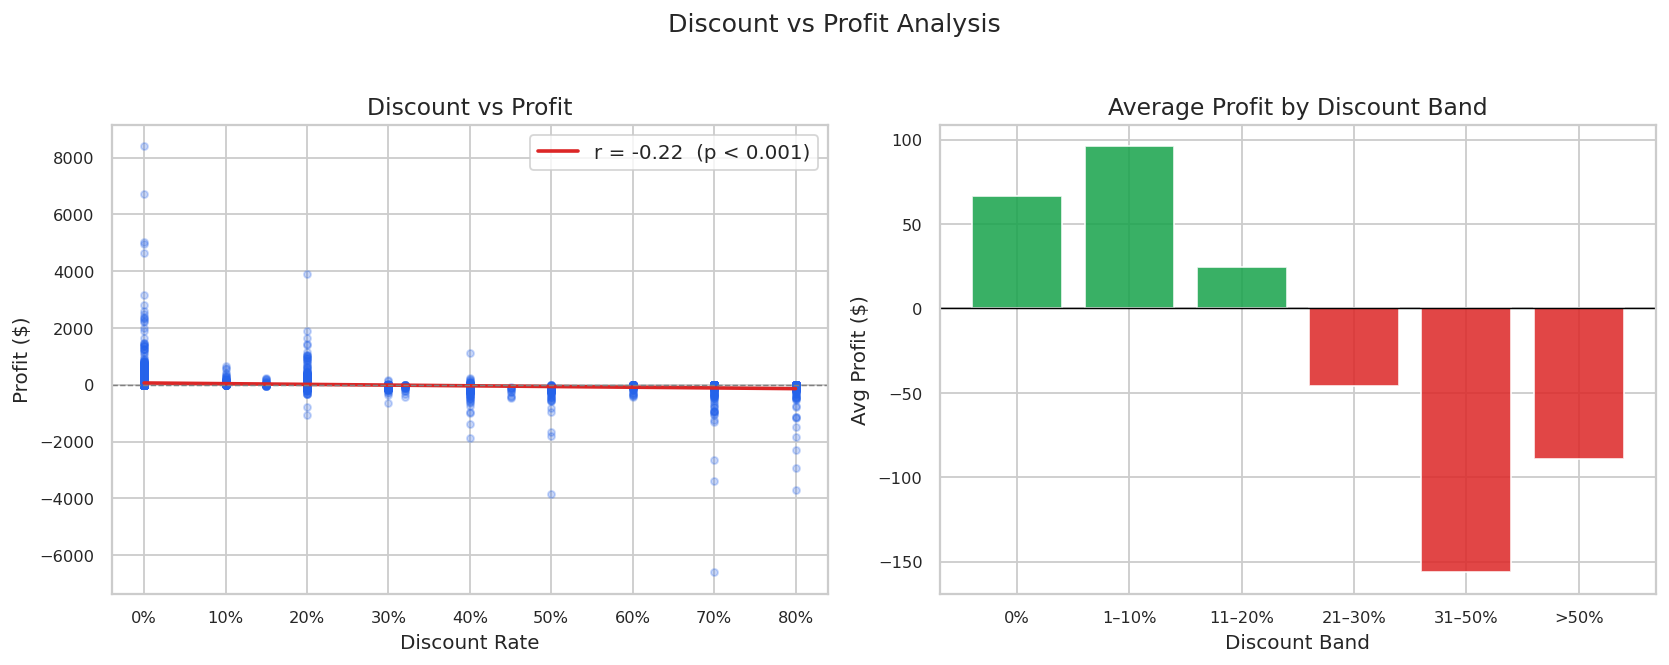

Pearson r (Discount vs Profit): -0.219  |  p-value: 2.70e-109

Average profit by discount band:
Discount Band
0%         66.90
1–10%      96.06
11–20%     24.74
21–30%    -45.68
31–50%   -156.28
>50%      -89.44
Name: Profit, dtype: float64


In [10]:
# ── Discount vs Profit ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(df['Discount'], df['Profit'],
                alpha=0.25, color=ACCENT, s=15)
# Regression line
m, b, r, p, _ = stats.linregress(df['Discount'], df['Profit'])
x_line = np.linspace(0, df['Discount'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='#DC2626', lw=2,
             label=f'r = {r:.2f}  (p < 0.001)')
axes[0].axhline(0, color='gray', lw=0.8, linestyle='--')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')
axes[0].set_title('Discount vs Profit')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()

# Average profit by discount band
df['Discount Band'] = pd.cut(df['Discount'],
                              bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
                              labels=['0%', '1–10%', '11–20%',
                                      '21–30%', '31–50%', '>50%'])
band_profit = df.groupby('Discount Band')['Profit'].mean()
colors = ['#16A34A' if v > 0 else '#DC2626' for v in band_profit.values]
axes[1].bar(band_profit.index, band_profit.values, color=colors, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Average Profit by Discount Band')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Avg Profit ($)')

plt.suptitle('Discount vs Profit Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig5_discount_vs_profit.png', bbox_inches='tight')
plt.show()

print(f'Pearson r (Discount vs Profit): {r:.3f}  |  p-value: {p:.2e}')
print()
print('Average profit by discount band:')
print(band_profit.round(2))

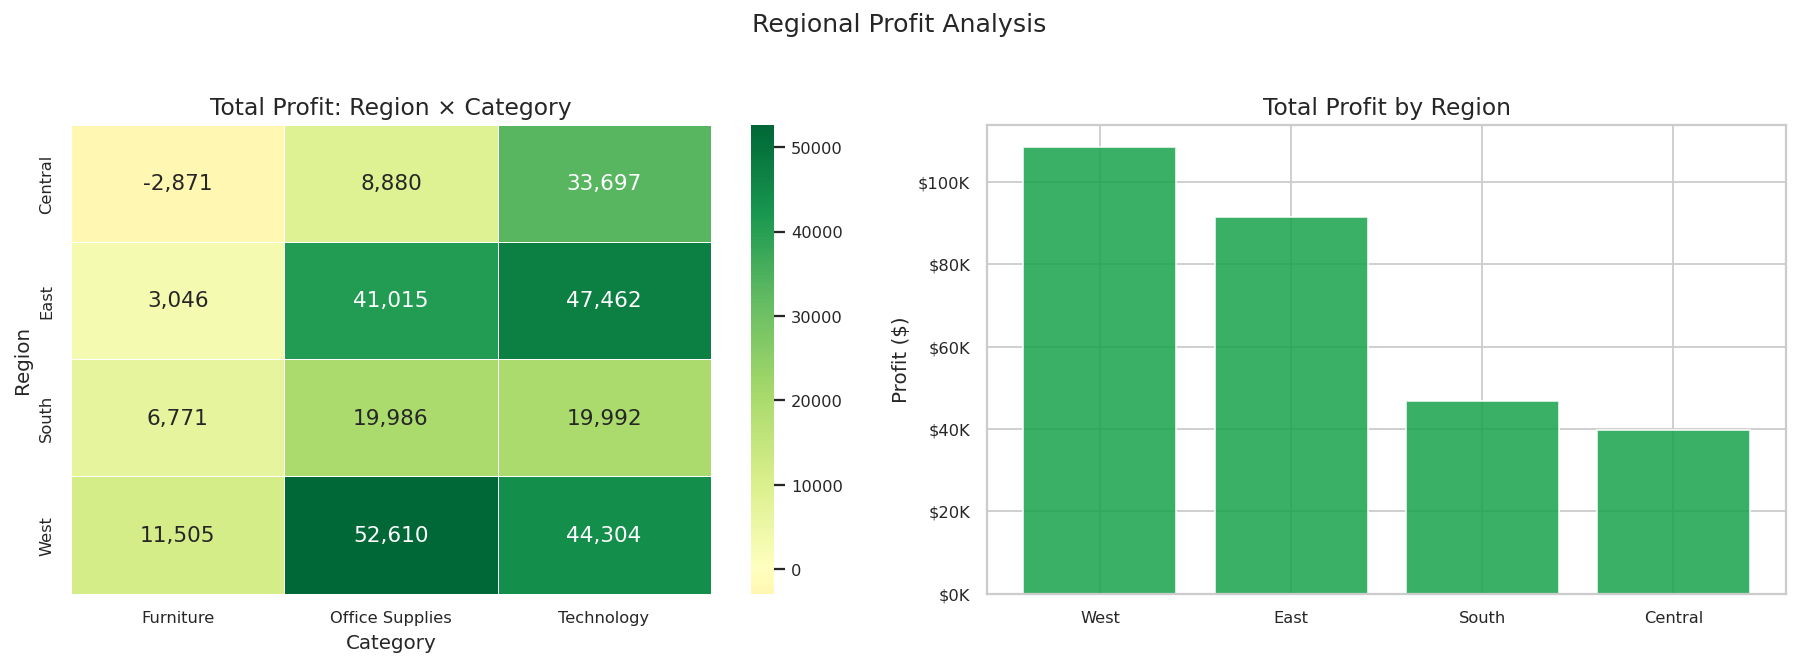

In [11]:
# ──Profit by Region and Category ───────────────────────────────────────
pivot = df.pivot_table(values='Profit', index='Region',
                        columns='Category', aggfunc='sum')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title('Total Profit: Region × Category')

# Region bar
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
bar_colors = ['#16A34A' if v > 0 else '#DC2626' for v in region_profit.values]
axes[1].bar(region_profit.index, region_profit.values,
            color=bar_colors, alpha=0.85)
axes[1].set_title('Total Profit by Region')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

plt.suptitle('Regional Profit Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig6_region_profit.png', bbox_inches='tight')
plt.show()

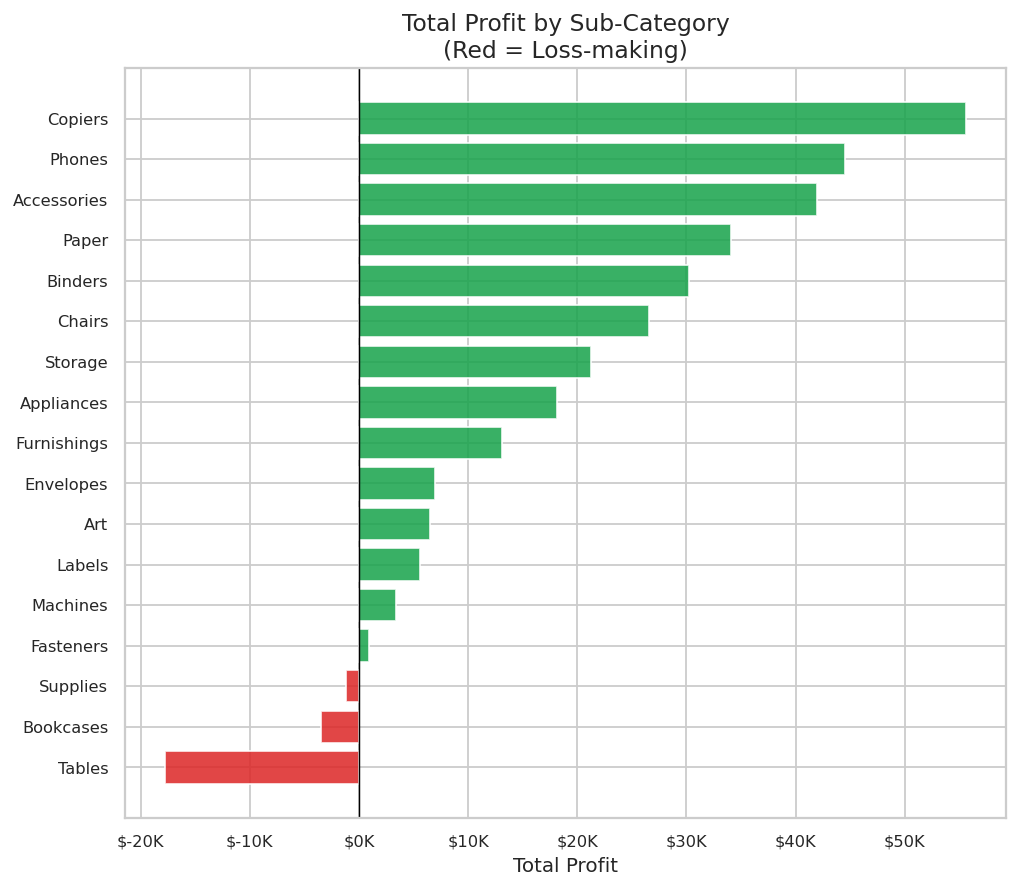

Loss-making sub-categories:
Sub-Category
Tables      -17725.48
Bookcases    -3472.56
Supplies     -1189.10
Name: Profit, dtype: float64


In [12]:
# ── Sub-Category Profit — find the loss-makers ──────────────────────────
sub_profit = (df.groupby('Sub-Category')['Profit']
                .sum()
                .sort_values())

colors = ['#DC2626' if v < 0 else '#16A34A' for v in sub_profit.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(sub_profit.index, sub_profit.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Total Profit by Sub-Category\n(Red = Loss-making)', fontsize=13)
ax.set_xlabel('Total Profit')
plt.tight_layout()
plt.savefig('fig7_subcategory_profit.png', bbox_inches='tight')
plt.show()

loss_makers = sub_profit[sub_profit < 0]
print('Loss-making sub-categories:')
print(loss_makers.round(2))

**Bivariate Observations:**
- **Discount and Profit are negatively correlated (r ≈ −0.22, p < 0.001)** — statistically significant. Orders with discounts above 20% are, on average, loss-making.
- The **Central region** is the weakest performer despite reasonable sales volumes — a margin problem, not a volume problem.
- **Tables and Bookcases are loss-making sub-categories** — they generate revenue but consistently destroy profit, likely due to over-discounting in the Furniture category.
- Technology is profitable across all regions; Furniture is problematic everywhere except the East.

---
## 5. Time Series Analysis



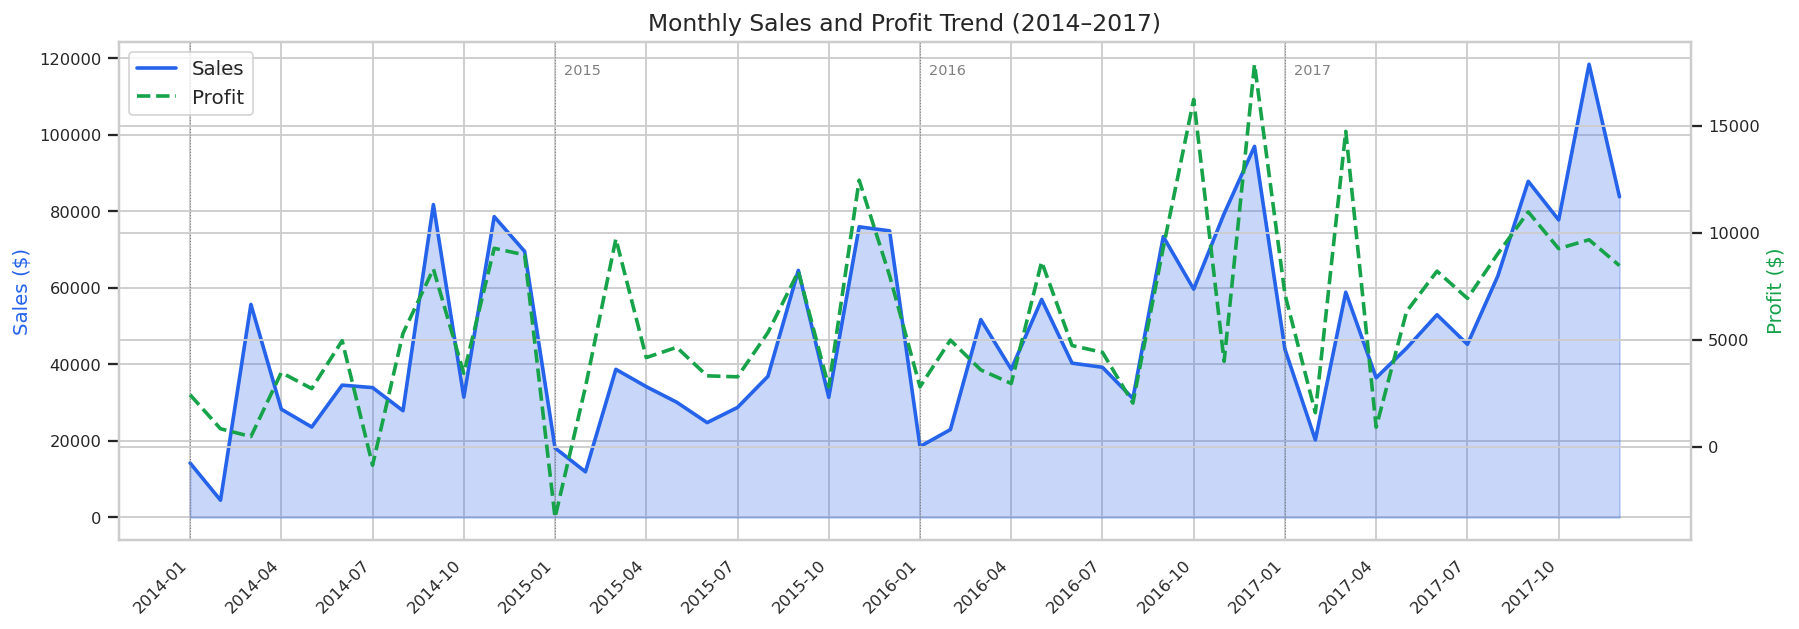

In [13]:
# ── Monthly Sales & Profit Trend ─────────────────────────────────────────
monthly = (df.groupby('Order Month')[['Sales', 'Profit']]
             .sum()
             .reset_index())
monthly['Order Month'] = monthly['Order Month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly['Order Month'], monthly['Sales'],
                 alpha=0.25, color=ACCENT)
ax1.plot(monthly['Order Month'], monthly['Sales'],
         color=ACCENT, lw=2, label='Sales')
ax2.plot(monthly['Order Month'], monthly['Profit'],
         color='#16A34A', lw=2, linestyle='--', label='Profit')


year_positions = [i for i, m in enumerate(monthly['Order Month']) if m.endswith('-01')]
for pos in year_positions:
    ax1.axvline(pos, color='gray', lw=0.6, linestyle=':')
    ax1.text(pos + 0.3, ax1.get_ylim()[1] * 0.93,
             monthly['Order Month'].iloc[pos][:4],
             fontsize=8, color='gray')

ax1.set_ylabel('Sales ($)', color=ACCENT)
ax2.set_ylabel('Profit ($)', color='#16A34A')
ax1.set_title('Monthly Sales and Profit Trend (2014–2017)', fontsize=13)
ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels([monthly['Order Month'].iloc[i] for i in range(0, len(monthly), 3)],
                     rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig8_monthly_trend.png', bbox_inches='tight')
plt.show()

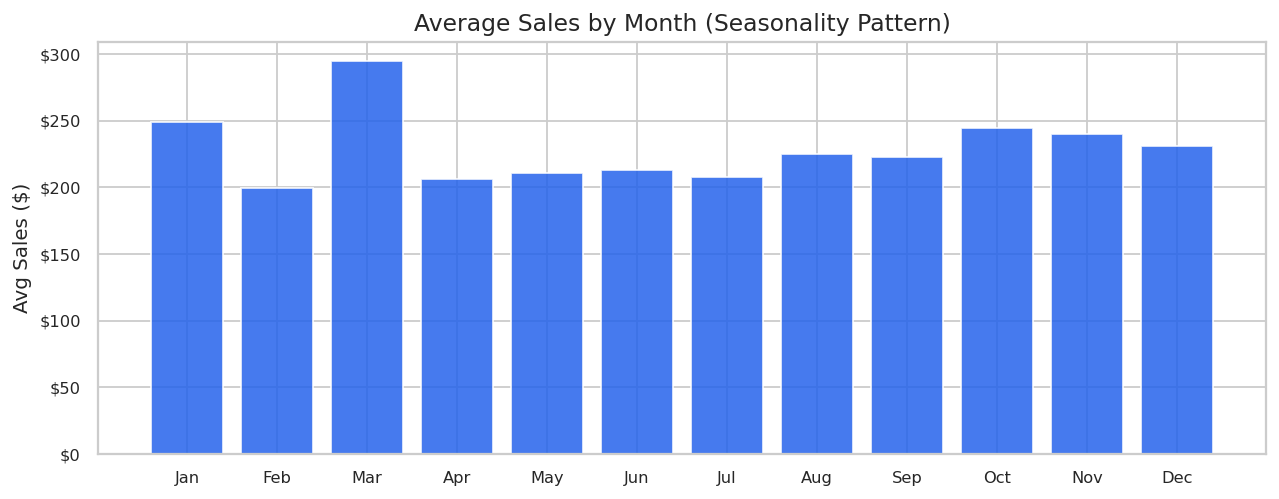

In [14]:
# ── Seasonality — Average Sales by Month Number ─────────────────────────
df['Month Num'] = df['Order Date'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

seasonal = df.groupby('Month Num')['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 13), seasonal.values, color=ACCENT, alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Average Sales by Month (Seasonality Pattern)', fontsize=13)
ax.set_ylabel('Avg Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('fig9_seasonality.png', bbox_inches='tight')
plt.show()

Year-over-Year Summary:
                Sales    Profit  Sales Growth %  Profit Growth %
Order Year                                                      
2014        484247.50  49543.97             NaN              NaN
2015        470532.51  61618.60           -2.83            24.37
2016        609205.60  81795.17           29.47            32.74
2017        733215.26  93439.27           20.36            14.24


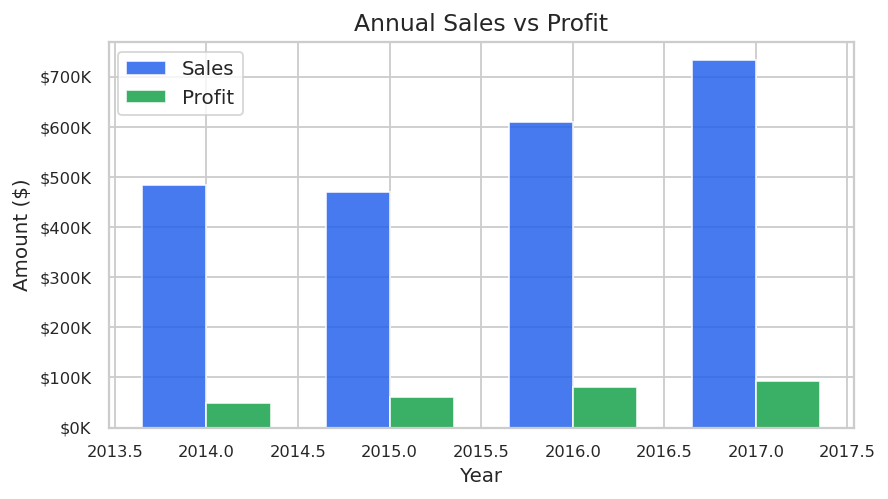

In [15]:
# ── YoY Revenue Growth ───────────────────────────────────────────────────
yearly = df.groupby('Order Year')[['Sales', 'Profit']].sum()
yearly['Sales Growth %'] = yearly['Sales'].pct_change() * 100
yearly['Profit Growth %'] = yearly['Profit'].pct_change() * 100

print('Year-over-Year Summary:')
print(yearly.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
x = yearly.index
w = 0.35
ax.bar(x - w/2, yearly['Sales'],   width=w, label='Sales',  color=ACCENT,    alpha=0.85)
ax.bar(x + w/2, yearly['Profit'],  width=w, label='Profit', color='#16A34A', alpha=0.85)
ax.set_title('Annual Sales vs Profit', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('fig10_annual_growth.png', bbox_inches='tight')
plt.show()

**Time Series Observations:**
- Revenue shows consistent **year-over-year growth** across all four years.
- There is a clear **Q4 seasonality spike** every year — November and December consistently outperform other months, driven by end-of-year purchasing cycles.
- **Profit growth lags sales growth** in some years — sales are scaling faster than margins, suggesting discounting pressure may be offsetting revenue gains.

---
## 6. Key Findings



In [16]:
# ── Supporting numbers for the findings ───────────────────────────────────────
high_disc = df[df['Discount'] > 0.20]
low_disc  = df[df['Discount'] <= 0.20]
print(f"Avg profit — discount > 20% : ${high_disc['Profit'].mean():.2f}")
print(f"Avg profit — discount ≤ 20% : ${low_disc['Profit'].mean():.2f}")
print()
print(f"Furniture profit margin  : {df[df['Category']=='Furniture']['Profit Margin'].mean():.1%}")
print(f"Technology profit margin : {df[df['Category']=='Technology']['Profit Margin'].mean():.1%}")
print(f"Office Supplies margin   : {df[df['Category']=='Office Supplies']['Profit Margin'].mean():.1%}")
print()
print('Q4 vs rest-of-year average monthly sales:')
q4  = df[df['Month Num'].isin([10,11,12])]['Sales'].sum() / (4*3)
rest = df[~df['Month Num'].isin([10,11,12])]['Sales'].sum() / (4*9)
print(f"  Q4 monthly avg  : ${q4:,.0f}")
print(f"  Rest-of-year avg: ${rest:,.0f}")
print(f"  Q4 premium      : +{(q4/rest - 1):.0%}")

Avg profit — discount > 20% : $-97.18
Avg profit — discount ≤ 20% : $49.04

Furniture profit margin  : 3.9%
Technology profit margin : 15.6%
Office Supplies margin   : 13.8%

Q4 vs rest-of-year average monthly sales:
  Q4 monthly avg  : $73,173
  Rest-of-year avg: $39,420
  Q4 premium      : +86%


---

## 📌 Key Findings Summary

1. **Discounts above 20% consistently destroy profit.**  
   Orders with discounts over 20% average a *loss*, while orders at 20% or below are profitable. The correlation between discount rate and profit is statistically significant (Pearson r ≈ −0.22, p < 0.001). The business is trading margin for volume — and losing.

2. **Furniture is a structural profit problem, not a volume problem.**  
   Furniture has the lowest profit margin of the three categories. Two of its sub-categories — Tables and Bookcases — are outright loss-making across all four years. High discounting in this category is the primary driver.

3. **Technology drives disproportionate profit relative to order volume.**  
   Technology accounts for the highest profit margin despite a moderate number of orders, making it the most capital-efficient category. Phones and Copiers lead sub-category profitability.

4. **The Central region underperforms on profit despite competitive sales.**  
   The Central region's issue is margin compression, not demand. It ranks mid-tier in sales but lowest in profit — suggesting regional discounting or pricing strategies need review.

5. **Q4 drives a significant revenue spike every year — a consistent seasonal pattern.**  
   Monthly average sales in Q4 are materially higher than the rest of the year. This pattern is consistent across all four years, indicating a reliable seasonal demand cycle the business can plan around.

---
*Analysis by Jasjot Singh | Dataset: Kaggle Superstore Sales*